In [1]:
# Install required libraries (only needed in Colab or fresh environments)
# !pip install transformers torchvision timm

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms
from transformers import SegformerForSemanticSegmentation, SegformerConfig
from torch.utils.tensorboard import SummaryWriter
from torch.utils.data import DataLoader, Dataset
import numpy as np
import os
import torch.nn.functional as F
import albumentations as A
from albumentations.pytorch import ToTensorV2

# ---------------------
# Dataset Setup
# ---------------------
class NPYSegmentationDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.images = sorted(os.listdir(image_dir))
        self.masks = sorted(os.listdir(mask_dir))
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image_path = os.path.join(self.image_dir, self.images[idx])
        mask_path  = os.path.join(self.mask_dir, self.masks[idx])

        image = np.load(image_path).astype(np.float32) / 255.0  # Normalizza se uint8
        mask  = np.load(mask_path).astype(np.int64)
        
        #print("Image shape:", image.shape)   # es. (256, 512, 3)
        #print("Label shape:", mask.shape) # es. (256, 512)
        #image = torch.from_numpy(image).permute(2, 0, 1)  # (H, W, C) -> (C, H, W) ??????????????

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask'].long()
        return image,mask

# ---------------------
# Config
# ---------------------
num_classes = 19
ignore_index = -1

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = A.Compose([
    #A.Resize(128, 256),
    #A.HorizontalFlip(p=0.5),
    #A.Rotate(limit=15, p=0.5),
    # A.RandomBrightnessContrast(p=0.2),  # solo per l'immagine
    # Per evitare problemi con la maschera, solo trasformazioni geometriche

    ToTensorV2()  # converte immagine e maschera in torch.Tensor
])

# ---------------------
# Dataloaders
# ---------------------
train_dataset = NPYSegmentationDataset("/kaggle/input/custom-cs/cityscapes/train/image", "/kaggle/input/custom-cs/cityscapes/train/label", transform=transform)
val_dataset   = NPYSegmentationDataset("/kaggle/input/custom-cs/cityscapes/val/image", "/kaggle/input/custom-cs/cityscapes/val/label", transform=A.Compose([A.Resize(128, 256),ToTensorV2()]))# no augmentation per val, solo resize + ToTensor
test_dataset = NPYSegmentationDataset("/kaggle/input/custom-cs/cityscapes/test/image", "/kaggle/input/custom-cs/cityscapes/test/label", transform=A.Compose([A.Resize(128, 256),ToTensorV2()]))# no augmentation per val, solo resize + ToTensor

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False, num_workers=2)

#for images, labels in train_loader:
#    print("Image batch shape:", images.shape)   # (B, 3, H, W)
#    print("Label batch shape:", labels.shape)   # (B, H, W)
#    break  # solo il primo batch

# ---------------------
# Model
# ---------------------

#Aggiungo un upsampler alla fine perché se no dovrei interpolare l'output durante il training, è uguale ma cosi scrivo di meno
class SegformerWithUpsample(nn.Module):
    def __init__(self, base_model, target_size):
        super().__init__()
        self.model = base_model
        self.target_size = target_size  # (H, W)

    def forward(self, pixel_values):
        logits = self.model(pixel_values=pixel_values).logits
        logits = F.interpolate(logits, size=self.target_size, mode="bilinear", align_corners=False)
        return logits

base_model = SegformerForSemanticSegmentation.from_pretrained(
    "nvidia/segformer-b0-finetuned-ade-512-512",
    num_labels=num_classes,
    ignore_mismatched_sizes=True
)

# Dummy input to get output shape
dummy_input = torch.randn(1, 3, 128, 256)
dummy_output = base_model(pixel_values=dummy_input).logits
upsample_size = (dummy_input.shape[2], dummy_input.shape[3])

model = SegformerWithUpsample(base_model, upsample_size).to(device)

# ---------------------
# Loss and Optimizer
# ---------------------
criterion = nn.CrossEntropyLoss(ignore_index=ignore_index)
optimizer = torch.optim.AdamW(model.parameters(), lr=6e-5)

# ---------------------
# Metrics
# ---------------------

def compute_pixel_accuracy(preds, targets):
    correct = (preds == targets).sum().item()
    total = (targets != -1).sum().item()  # Esclude i pixel con label -1
    return correct / total if total > 0 else 0.0

def compute_mean_iou(preds, labels, num_classes, ignore_index=255):
    ious = []
    preds = preds.view(-1)
    labels = labels.view(-1)
    mask = labels != ignore_index
    preds = preds[mask]
    labels = labels[mask]

    for cls in range(num_classes):
        pred_inds = preds == cls
        target_inds = labels == cls
        intersection = (pred_inds & target_inds).sum().item()
        union = (pred_inds | target_inds).sum().item()
        if union == 0:
            ious.append(float('nan'))
        else:
            ious.append(intersection / union)
    return np.nanmean(ious)

# ---------------------
# Validation
# ---------------------
def validate(model, dataloader, criterion):
    model.eval()
    val_loss = 0.0
    total_iou = 0.0
    total_acc = 0.0
    num_batches = 0

    with torch.no_grad():
        for images, masks in dataloader:
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)
            loss = criterion(outputs, masks)
            val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            iou = compute_mean_iou(preds, masks, num_classes)
            acc = compute_pixel_accuracy(preds, masks)

            total_iou += iou
            total_acc += acc
            num_batches += 1

    return val_loss / num_batches, total_iou / num_batches, total_acc / num_batches

# ---------------------
# Training Loop
# ---------------------
def train(model, train_loader, val_loader, optimizer, criterion, num_epochs=10, log_dir="runs/segformer"):
    writer = SummaryWriter(log_dir)
    best_miou = 0.0

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0

        for images, masks in train_loader:
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(pixel_values=images) #altezza e larghezza sono /4, vedi la documentazione

            ###??????????
            #outputs = F.interpolate(outputs, size=masks.shape[-2:], mode="bilinear", align_corners=False) #soluzione per portare alla stessa dimensione??
            loss = criterion(outputs, masks)
            

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        #print(model)
        #print(val_loader)
        #print(criterion)
        avg_train_loss = running_loss / len(train_loader)
        val_loss, val_iou, val_acc = validate(model, val_loader, criterion)

        print(f"Epoch [{epoch+1}/{num_epochs}] "
              f"Train Loss: {avg_train_loss:.4f} | "
              f"Val Loss: {val_loss:.4f} | "
              f"Val mIoU: {val_iou:.4f} | "
              f"Val PixelAcc: {val_acc:.4f}")

        # Scrivi le metriche su TensorBoard
        writer.add_scalar("Loss/train", avg_train_loss, epoch + 1)
        writer.add_scalar("Loss/val", val_loss, epoch + 1)
        writer.add_scalar("mIoU/val", val_iou, epoch + 1)
        writer.add_scalar("PixelAccuracy/val", val_acc, epoch + 1)

        if val_iou > best_miou:
            best_miou = val_iou
            torch.save(model.state_dict(), f"{log_dir}/best_model.pth")
            print(f"Salvato modello all'epoca {epoch+1} con mIoU {val_iou:.4f}")

    writer.close()

# ---------------------
# Avvio training
# ---------------------
train(model, train_loader, val_loader, optimizer, criterion, num_epochs=50)


2025-06-20 13:06:26.917831: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1750424787.129056      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1750424787.191304      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
/usr/local/lib/python3.11/dist-packages/albumentations/__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.8' (you have '2.0.5'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


config.json:   0%|          | 0.00/6.88k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/15.0M [00:00<?, ?B/s]

Some weights of SegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/segformer-b0-finetuned-ade-512-512 and are newly initialized because the shapes did not match:
- decode_head.classifier.bias: found shape torch.Size([150]) in the checkpoint and torch.Size([19]) in the model instantiated
- decode_head.classifier.weight: found shape torch.Size([150, 256, 1, 1]) in the checkpoint and torch.Size([19, 256, 1, 1]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch [1/50] Train Loss: 1.4998 | Val Loss: 1.0990 | Val mIoU: 0.1293 | Val PixelAcc: 0.6672
Salvato modello all'epoca 1 con mIoU 0.1293
Epoch [2/50] Train Loss: 0.9798 | Val Loss: 0.9219 | Val mIoU: 0.1581 | Val PixelAcc: 0.7144
Salvato modello all'epoca 2 con mIoU 0.1581
Epoch [3/50] Train Loss: 0.8448 | Val Loss: 0.8258 | Val mIoU: 0.1773 | Val PixelAcc: 0.7491
Salvato modello all'epoca 3 con mIoU 0.1773
Epoch [4/50] Train Loss: 0.7686 | Val Loss: 0.7638 | Val mIoU: 0.1860 | Val PixelAcc: 0.7666
Salvato modello all'epoca 4 con mIoU 0.1860
Epoch [5/50] Train Loss: 0.6990 | Val Loss: 0.7149 | Val mIoU: 0.1972 | Val PixelAcc: 0.7801
Salvato modello all'epoca 5 con mIoU 0.1972
Epoch [6/50] Train Loss: 0.6362 | Val Loss: 0.6395 | Val mIoU: 0.2136 | Val PixelAcc: 0.8077
Salvato modello all'epoca 6 con mIoU 0.2136
Epoch [7/50] Train Loss: 0.5911 | Val Loss: 0.5931 | Val mIoU: 0.2286 | Val PixelAcc: 0.8197
Salvato modello all'epoca 7 con mIoU 0.2286
Epoch [8/50] Train Loss: 0.5579 | Val Los

In [2]:
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
import numpy as np
from sklearn.metrics import confusion_matrix

def compute_metrics(preds, labels, num_classes):
    cm = confusion_matrix(
        labels.flatten(),
        preds.flatten(),
        labels=list(range(num_classes))
    )
    intersection = np.diag(cm)
    union = cm.sum(1) + cm.sum(0) - intersection
    iou = intersection / np.maximum(union, 1)
    miou = np.mean(iou)
    pixel_acc = np.sum(intersection) / np.sum(cm)
    return pixel_acc, miou, iou

def show_rescaled_image(img_tensor):
    """
    Visualizza un'immagine torch.Tensor [3, H, W] anche se ha valori molto piccoli
    """
    img = img_tensor.detach().cpu()
    if img.dtype != torch.float32:
        img = img.float()

    # Riscalamento automatico al range [0, 1]
    min_val = img.min()
    max_val = img.max()
    img = (img - min_val) / (max_val - min_val + 1e-8)

    img = img.permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)
    
    plt.imshow(img)
    plt.axis('off')
    plt.title("Rescaled RGB Image")
    plt.show()

def visualize_prediction(image, label, prediction, class_colors=None):
    print(image.shape)
    print(image.min().item())
    print(image.max().item())
    #image_np = image.permute(1, 2, 0).cpu().numpy()
    label_np = label.cpu().numpy()
    pred_np = prediction.cpu().numpy()

    if class_colors is not None:
        label_np = np.stack([class_colors[c] for c in label_np.flatten()]).reshape(label_np.shape + (3,))
        pred_np = np.stack([class_colors[c] for c in pred_np.flatten()]).reshape(pred_np.shape + (3,))

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    show_rescaled_image(image)
    #plt.imshow(image_np)
    #plt.title("Input Image")

    plt.subplot(1, 3, 2)
    plt.imshow(label_np)
    plt.title("Ground Truth")

    plt.subplot(1, 3, 3)
    plt.imshow(pred_np)
    plt.title("Prediction")

    plt.tight_layout()
    plt.show()



def test_model(model, test_loader, num_classes=19, show_example=True, class_colors=None):
    model.eval()
    all_preds = []
    all_labels = []
    example_shown = False

    with torch.no_grad():
        for images, masks in test_loader:
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(pixel_values=images) #altezza e larghezza sono /4, vedi la documentazione
            
            loss = criterion(outputs, masks)

            if outputs.shape[-2:] != masks.shape[-2:]:
                outputs = F.interpolate(outputs, size=masks.shape[-2:], mode='bilinear', align_corners=False)

            preds = torch.argmax(outputs, dim=1)

            all_preds.append(preds.cpu())
            all_labels.append(masks.cpu())

            # Mostra solo un esempio
            if show_example and not example_shown:
                visualize_prediction(images[7], masks[7], preds[7], class_colors)
                example_shown = True

    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()

    pixel_acc, miou, iou_per_class = compute_metrics(all_preds, all_labels, num_classes)

    print(f"\nTest Results:")
    print(f"Pixel Accuracy: {pixel_acc:.4f}")
    print(f"Mean IoU: {miou:.4f}")
    print("IoU per class:")
    for i, iou in enumerate(iou_per_class):
        print(f"  Class {i}: {iou:.4f}")

    return pixel_acc, miou, iou_per_class

torch.Size([3, 128, 256])
3.075740460189991e-05
0.003921568859368563


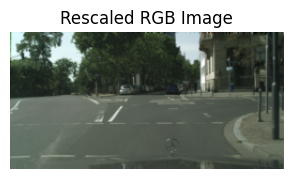

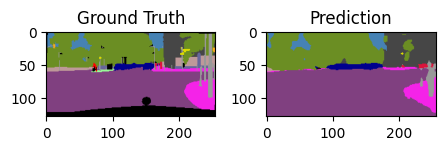


Test Results:
Pixel Accuracy: 0.8559
Mean IoU: 0.3448
IoU per class:
  Class 0: 0.9225
  Class 1: 0.4865
  Class 2: 0.7518
  Class 3: 0.1672
  Class 4: 0.0584
  Class 5: 0.0870
  Class 6: 0.0290
  Class 7: 0.1345
  Class 8: 0.7803
  Class 9: 0.4464
  Class 10: 0.8440
  Class 11: 0.2964
  Class 12: 0.0375
  Class 13: 0.6880
  Class 14: 0.1130
  Class 15: 0.0785
  Class 16: 0.3488
  Class 17: 0.1430
  Class 18: 0.1387


(0.8559492848493289,
 0.34481752075766403,
 array([0.92254282, 0.48652866, 0.75179229, 0.16716828, 0.05835203,
        0.08698822, 0.0290016 , 0.13448459, 0.78034477, 0.44636962,
        0.84400435, 0.29644296, 0.03747786, 0.68804436, 0.113036  ,
        0.07845345, 0.3487798 , 0.14298511, 0.1387361 ]))

In [3]:
class_colors = [
    (128, 64,128),   # 0: road fucsia scuro
    (244, 35,232),   # 1: sidewalk fucsia
    ( 70, 70, 70),   # 2: building grigio scuro
    (102,102,156),   # 3: wall??? azzurrino scuro
    (190,153,153),   # 4: fence??? rosa chiarissimo
    (153,153,153),   # 5: pole  grigio
    (250,170, 30),   # 6: traffic light arancione
    (220,220,  0),   # 7: traffic sign giallo
    (107,142, 35),   # 8: vegetation verde scuretto
    (152,251,152),   # 9: terrain verde chiarissimo
    ( 70,130,180),   #10: sky azzurro 
    (220, 20, 60),   #11: person rosa-rosso fluo
    (255,  0,  0),   #12: rider rosso
    (  0,  0,142),   #13: car bllu scuro
    (  0,  0, 70),   #14: truck blu molto piu scuro
    (  0, 60,100),   #15: bus azzurro scuro
    (  0, 80,100),   #16: train verde acqua scuro
    (  0,  0,230),   #17: motorcycle blu
    (0, 0, 0),   #18: unlabeled nero
]

test_model(model, test_loader, num_classes=19, class_colors=class_colors)